# 03. Modelagem e Comparação de Modelos

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from src import data_prep, modeling, evaluation, interpretability, visualization

visualization.set_style()
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

RANDOM_STATE = 42
PROCESSED_DIR = ROOT / "data" / "processed"
MODELS_DIR = ROOT / "models"

In [2]:
X_train, X_test, y_train, y_test = data_prep.load_processed_split()
target = data_prep.TARGET
features = list(X_train.columns)

baseline = modeling.get_baseline()
baseline.fit(X_train, y_train)
baseline_metrics = evaluation.regression_metrics(y_test, baseline.predict(X_test))
baseline_metrics

{'MAE': 418.92365255951967,
 'RMSE': 520.4544841877326,
 'R2': -0.0017966725261557848,
 'MAPE': 0.19805165726331037}

## 5. Comparar os modelos

In [3]:
models = modeling.get_models()
results_df, preds_test = evaluation.evaluate_models(models, X_train, y_train, X_test, y_test)
results_df

,modelo,MAE,RMSE,R2,MAPE
0,GradientBoosting,283.708130,352.559216,0.540296,0.130046
1,Ridge,288.399634,357.656691,0.526907,0.130949
2,Linear,288.415606,357.686779,0.526827,0.130951
3,RandomForest,287.368908,362.780748,0.513254,0.132757
4,XGBoost,317.876756,394.697322,0.423841,0.143301
5,DecisionTree,352.062169,440.616263,0.281982,0.162488


## 6. Avaliar MAE, RMSE, R² e MAPE

In [4]:
comparison = pd.concat([
    pd.DataFrame([{"modelo": "Baseline (média)", **baseline_metrics}]),
    results_df,
], ignore_index=True).sort_values("RMSE").reset_index(drop=True)
comparison["ganho_RMSE_vs_baseline"] = 1 - comparison["RMSE"] / baseline_metrics["RMSE"]
comparison.to_csv(PROCESSED_DIR / "model_comparison.csv", index=False)
comparison

,modelo,MAE,RMSE,R2,MAPE,ganho_RMSE_vs_baseline
0,GradientBoosting,283.708130,352.559216,0.540296,0.130046,0.322594
1,Ridge,288.399634,357.656691,0.526907,0.130949,0.312799
2,Linear,288.415606,357.686779,0.526827,0.130951,0.312741
3,RandomForest,287.368908,362.780748,0.513254,0.132757,0.302954
4,XGBoost,317.876756,394.697322,0.423841,0.143301,0.241630
5,DecisionTree,352.062169,440.616263,0.281982,0.162488,0.153401
6,Baseline (média),418.923653,520.454484,-0.001797,0.198052,0.000000


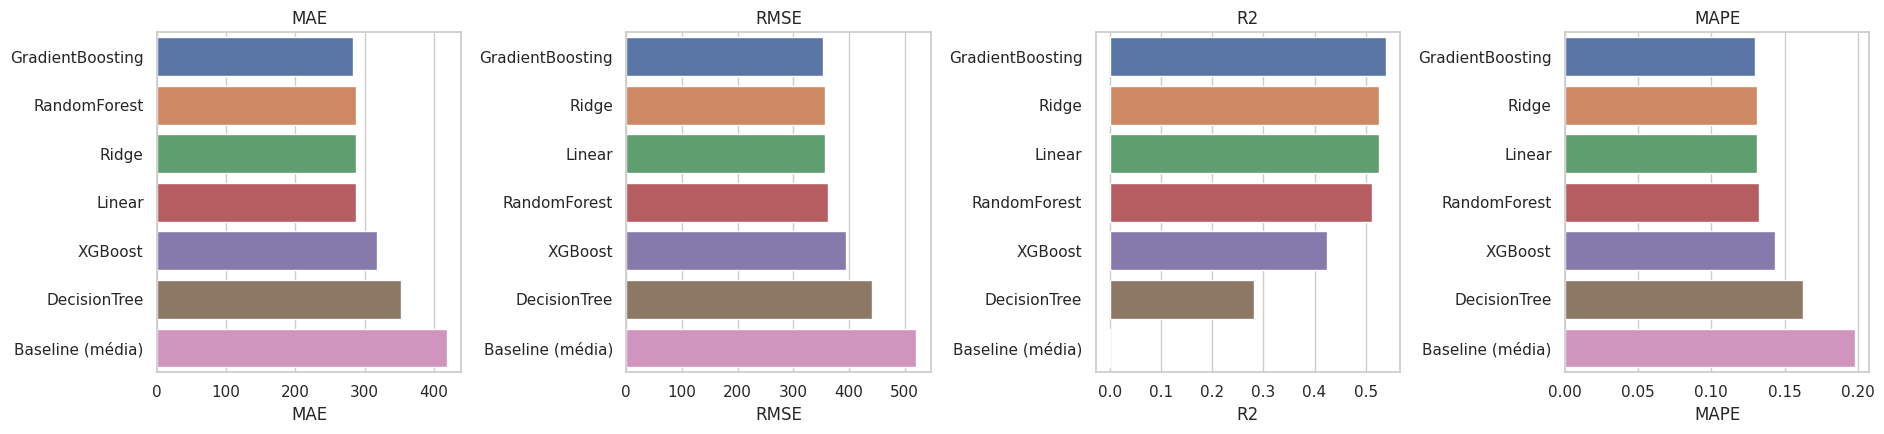

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(19, 4.5))
for ax, metric in zip(axes, ["MAE", "RMSE", "R2", "MAPE"]):
    order = comparison.sort_values(metric, ascending=(metric != "R2"))
    sns.barplot(data=order, x=metric, y="modelo", ax=ax, palette="deep")
    ax.set_title(metric)
    ax.set_ylabel("")
plt.tight_layout()
plt.show()

* Todos os modelos superam o baseline com boa margem, inclusive em MAPE (reportamos essa métrica junto de MAE/RMSE/R² para checar o erro proporcional, já que a target varia de ~R\$600 a ~R\$4.400).
* Linear, Ridge e Gradient Boosting ficam à frente no teste, o que é coerente com as correlações vistas na EDA, que já indicavam relações majoritariamente lineares e aditivas, com algum ruído. É por causa dessa proximidade entre os três melhores candidatos que a escolha do modelo final (notebook 05) não pode se basear numa diferença pequena medida uma única vez no teste. Voltamos a isso na seção de teste de significância, mais à frente.

## 7. Ver previsto contra observado

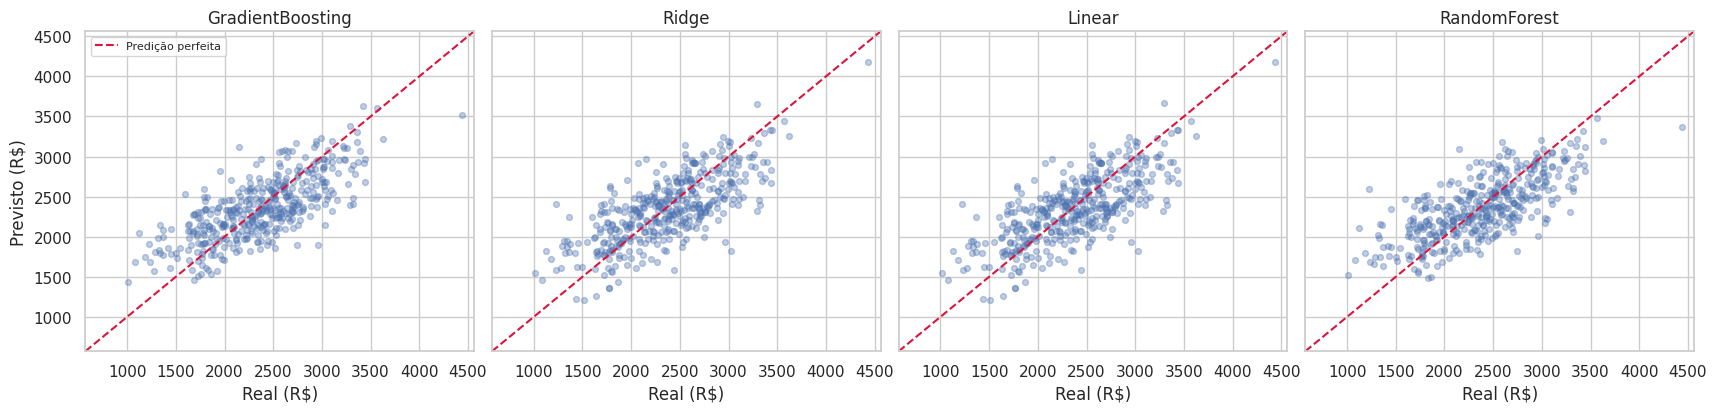

In [6]:
top_models = comparison[comparison["modelo"] != "Baseline (média)"].sort_values("RMSE").head(4)["modelo"].tolist()

fig, axes = plt.subplots(1, len(top_models), figsize=(4.3 * len(top_models), 4.3), sharex=True, sharey=True)
lims = [y_train.min() * 0.95, y_train.max() * 1.05]
for ax, name in zip(axes, top_models):
    visualization.plot_pred_vs_actual(ax, y_test, preds_test[name], name, lims)
    ax.set_xlabel("Real (R$)")
axes[0].set_ylabel("Previsto (R$)")
axes[0].legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

* Os pontos ficam bem próximos da linha no meio do intervalo de gasto.
* Para gasto baixo, os modelos tendem a prever a mais. Para gasto alto, tendem a prever a menos.
* Um cliente aparece como outlier nos quatro modelos, com erro bem maior que o normal.
* Ridge e Linear têm padrões quase iguais entre si.
* GradientBoosting e RandomForest erram mais nas pontas do intervalo, principalmente em valores baixos.

## 8. Experimento: `log1p(renda)` ajuda os modelos lineares?

A EDA (notebook 01) mostrou que `renda` tem uma cauda direita longa, com outliers de clientes de alta renda. Testamos aqui se aplicar `log1p` em `renda` antes de padronizar melhora o Ridge, ou seja, se comprimir essa cauda ajuda os modelos lineares.

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.linear_model import Ridge
from sklearn.compose import ColumnTransformer

def log_renda_pipeline():
    log_cols = ["renda"]
    other_cols = [c for c in features if c not in log_cols]
    pre = ColumnTransformer([
        ("log_renda", Pipeline([("log", FunctionTransformer(np.log1p)), ("scale", StandardScaler())]), log_cols),
        ("scale_rest", StandardScaler(), other_cols),
    ])
    return Pipeline([("pre", pre), ("model", Ridge(alpha=1.0, random_state=RANDOM_STATE))])

rows = []
for s in range(10):
    Xtr, Xte, ytr, yte = data_prep.make_split(*data_prep.get_feature_target(
        pd.read_csv(PROCESSED_DIR / "dataset_limpo.csv"), target), random_state=s)

    base = modeling.get_models()["Ridge"]
    base.fit(Xtr, ytr)
    rmse_base = evaluation.regression_metrics(yte, base.predict(Xte))["RMSE"]

    logp = log_renda_pipeline()
    logp.fit(Xtr, ytr)
    rmse_log = evaluation.regression_metrics(yte, logp.predict(Xte))["RMSE"]

    rows.append({"seed": s, "RMSE_renda_original": rmse_base, "RMSE_log1p_renda": rmse_log})

log_experiment = pd.DataFrame(rows)
print(log_experiment)
print("\nMédia RMSE (renda original):", log_experiment["RMSE_renda_original"].mean().round(2))
print("Média RMSE (log1p renda):    ", log_experiment["RMSE_log1p_renda"].mean().round(2))

   seed  RMSE_renda_original  RMSE_log1p_renda
0     0           344.508005        352.933811
1     1           363.832574        375.535996
2     2           370.274329        372.480202
3     3           353.589763        363.092889
4     4           383.743469        387.462174
5     5           362.780630        371.243919
6     6           355.717950        359.047759
7     7           355.164705        356.427795
8     8           368.560607        384.513798
9     9           362.653796        369.372746

Média RMSE (renda original): 362.08
Média RMSE (log1p renda):     369.21


`log1p(renda)` piora o RMSE de forma consistente nas 10 divisões testadas, então não é uma questão de sorte do split. Isso é coerente com a relação aproximadamente linear entre `renda` e `gasto_mensal` que já tínhamos visto na EDA: não há ganho em comprimir a cauda da distribuição de `renda` aqui. Por isso, mantivemos `renda` na escala original, sem transformação. É um resultado negativo, mas documentado: testamos a alternativa e descartamos com evidência, não por falta de tentativa.